## Import modules

In [45]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## Loading the dataset

In [46]:
df = pd.read_csv("Loan Prediction Dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [47]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


## Preprocessing the dataset

In [49]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [50]:
# filling the missing values for numerical terms - mean
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].mean())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mean())

In [51]:
# filling the missing values for categorical terms - mode
df['Gender'] = df["Gender"].fillna(df['Gender'].mode()[0])
df['Married'] = df["Married"].fillna(df['Married'].mode()[0])
df['Dependents'] = df["Dependents"].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df["Self_Employed"].fillna(df['Self_Employed'].mode()[0])

In [52]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Exploratory Data Analysis

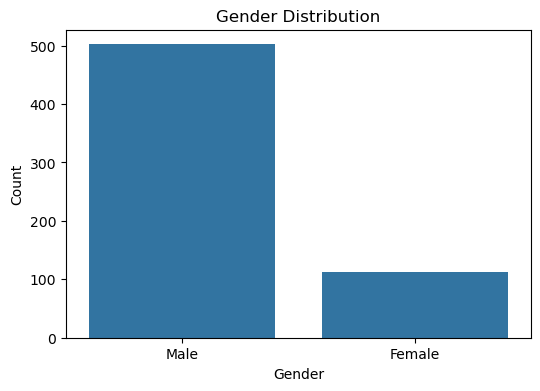

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

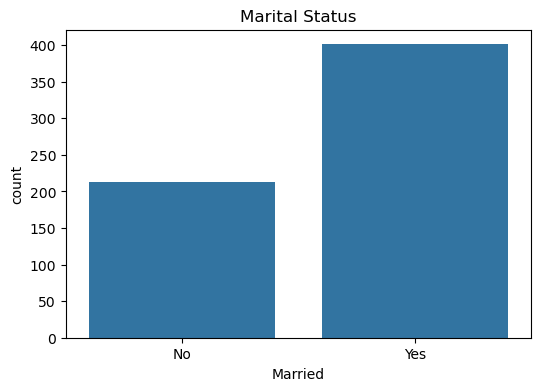

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x='Married', data=df)
plt.title("Marital Status")
plt.show()

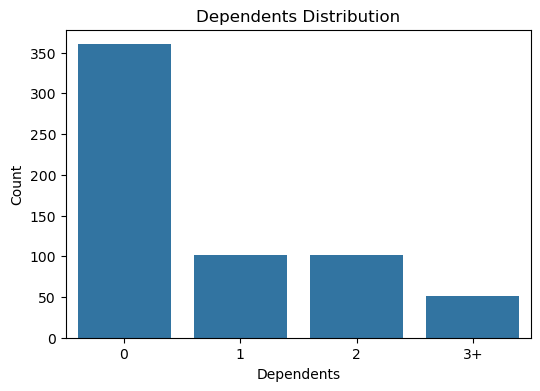

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x='Dependents', data=df)
plt.title("Dependents Distribution")
plt.xlabel("Dependents")
plt.ylabel("Count")
plt.show()

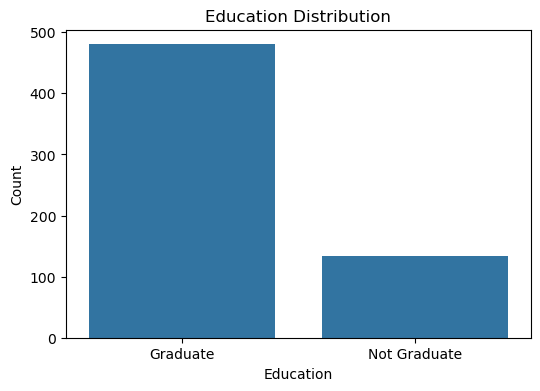

In [56]:
plt.figure(figsize=(6,4))
sns.countplot(x='Education', data=df)
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()

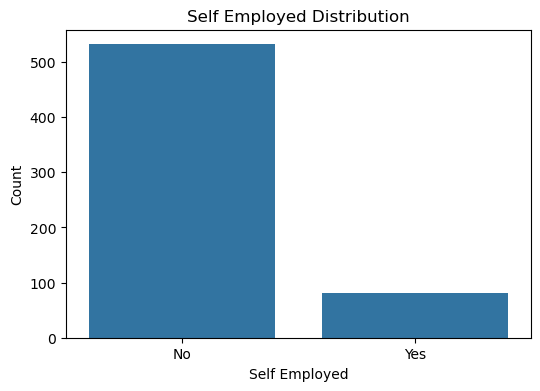

In [57]:
plt.figure(figsize=(6,4))
sns.countplot(x='Self_Employed', data=df)
plt.title("Self Employed Distribution")
plt.xlabel("Self Employed")
plt.ylabel("Count")
plt.show()

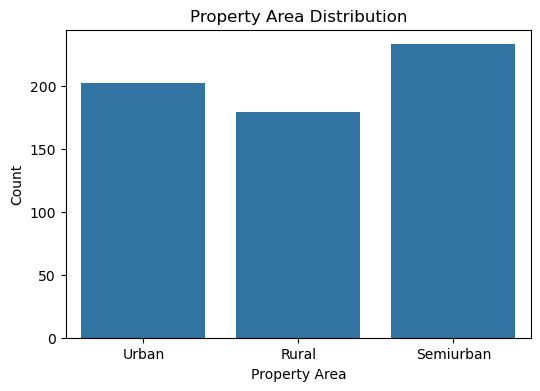

In [58]:
plt.figure(figsize=(6,4))
sns.countplot(x='Property_Area', data=df)
plt.title("Property Area Distribution")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.show()

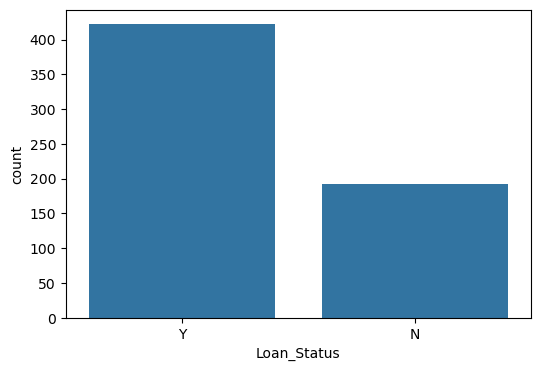

In [59]:
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.show()

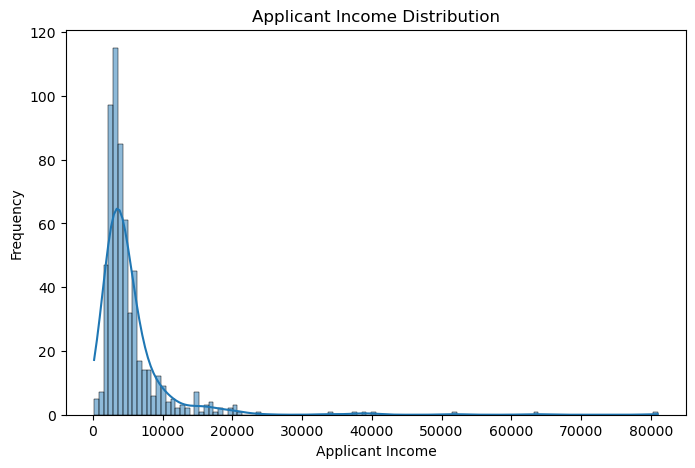

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df["ApplicantIncome"], kde=True)
plt.title("Applicant Income Distribution")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

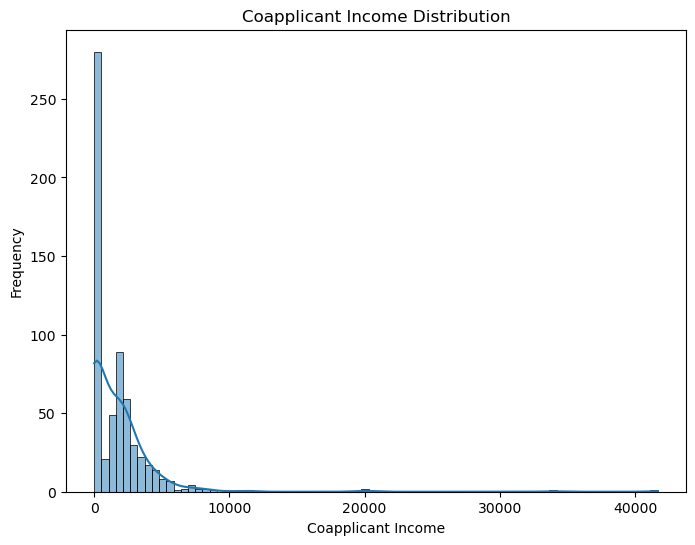

In [61]:
plt.figure(figsize=(8,6))
sns.histplot(df["CoapplicantIncome"], kde=True)
plt.title("Coapplicant Income Distribution")
plt.xlabel("Coapplicant Income")
plt.ylabel("Frequency")
plt.show()

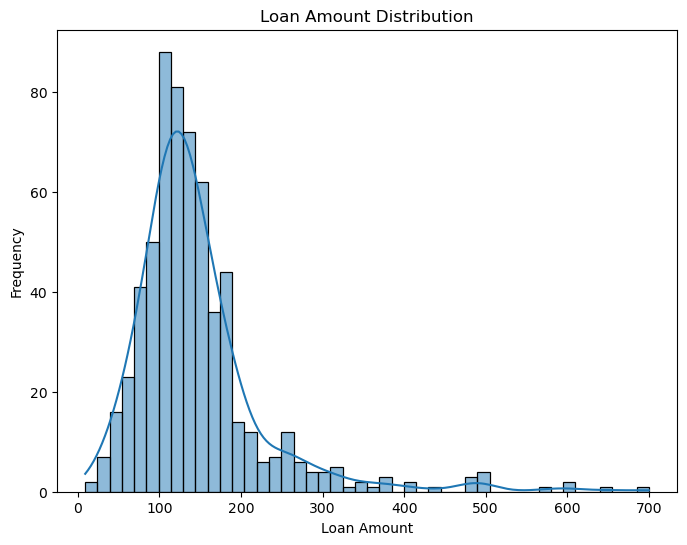

In [62]:
plt.figure(figsize=(8,6))
sns.histplot(df["LoanAmount"], kde=True)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")
plt.ylabel("Frequency")
plt.show()

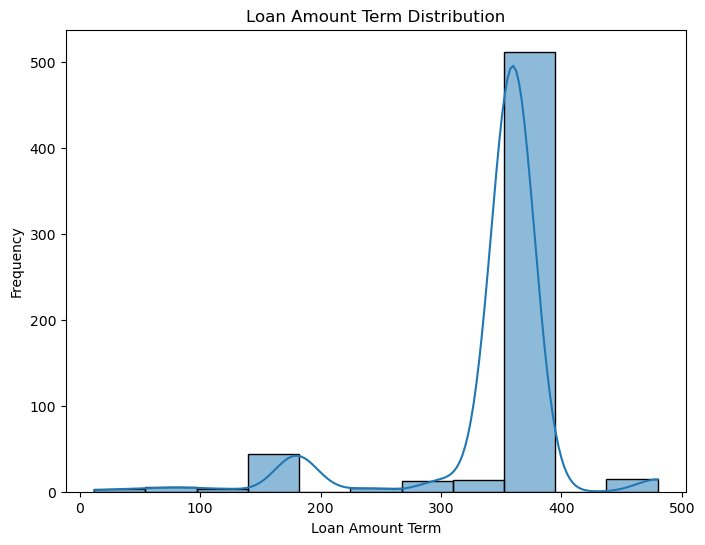

In [63]:
plt.figure(figsize=(8,6))
sns.histplot(df['Loan_Amount_Term'].dropna(), kde=True)
plt.title("Loan Amount Term Distribution")
plt.xlabel("Loan Amount Term")
plt.ylabel("Frequency")
plt.show()

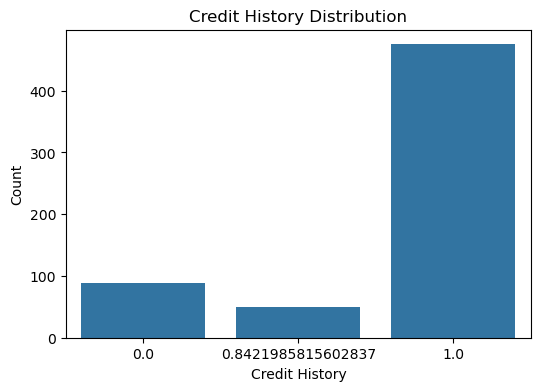

In [64]:
plt.figure(figsize=(6,4))
sns.countplot(x='Credit_History', data=df)
plt.title("Credit History Distribution")
plt.xlabel("Credit History")
plt.ylabel("Count")
plt.show()

## Creation of new attributes

In [65]:
# total income
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0


## Log Transformation

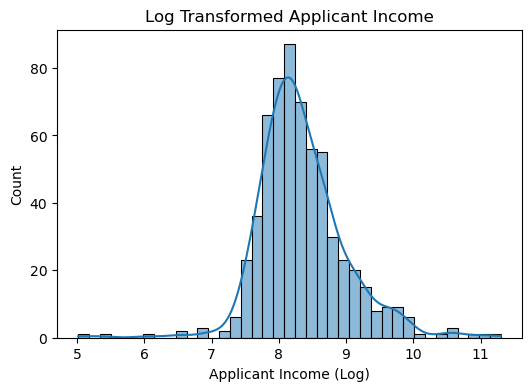

In [66]:
# apply log transformation
df['ApplicantIncomeLog'] = np.log(df['ApplicantIncome'] + 1)
plt.figure(figsize=(6,4))
sns.histplot(df["ApplicantIncomeLog"], kde=True)
plt.title("Log Transformed Applicant Income")
plt.xlabel("Applicant Income (Log)")
plt.show()

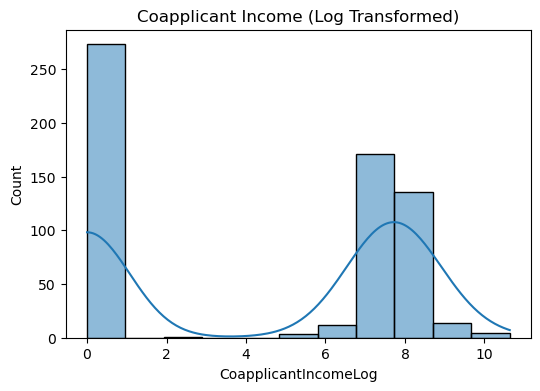

In [67]:
df['CoapplicantIncomeLog'] = np.log(df['CoapplicantIncome'] + 1)
plt.figure(figsize=(6,4))
sns.histplot(df['CoapplicantIncomeLog'], kde=True)
plt.title("Coapplicant Income (Log Transformed)")
plt.show()

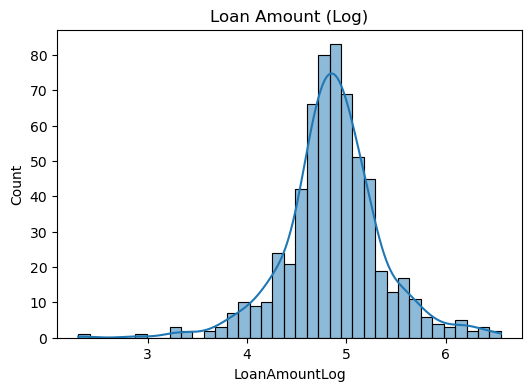

In [68]:
df['LoanAmountLog'] = np.log(df['LoanAmount'] + 1)
plt.figure(figsize=(6,4))
sns.histplot(df['LoanAmountLog'], kde=True)
plt.title("Loan Amount (Log)")
plt.show()

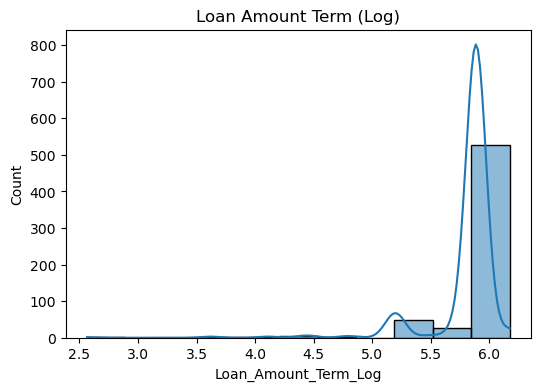

In [69]:
df['Loan_Amount_Term_Log'] = np.log(df['Loan_Amount_Term'] + 1)
plt.figure(figsize=(6,4))
sns.histplot(df['Loan_Amount_Term_Log'], kde=True)
plt.title("Loan Amount Term (Log)")
plt.show()

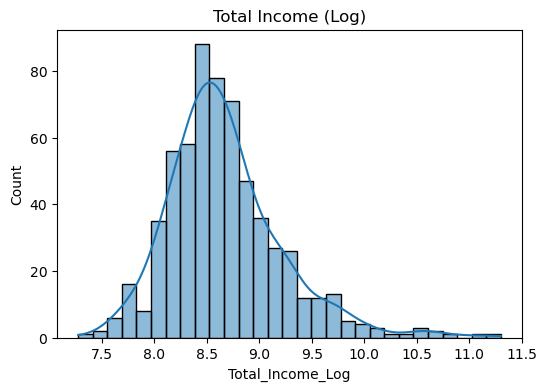

In [70]:
df['Total_Income_Log'] = np.log(df['Total_Income'] + 1)
plt.figure(figsize=(6,4))
sns.histplot(df['Total_Income_Log'], kde=True)
plt.title("Total Income (Log)")
plt.show()

## Coorelation Matrix

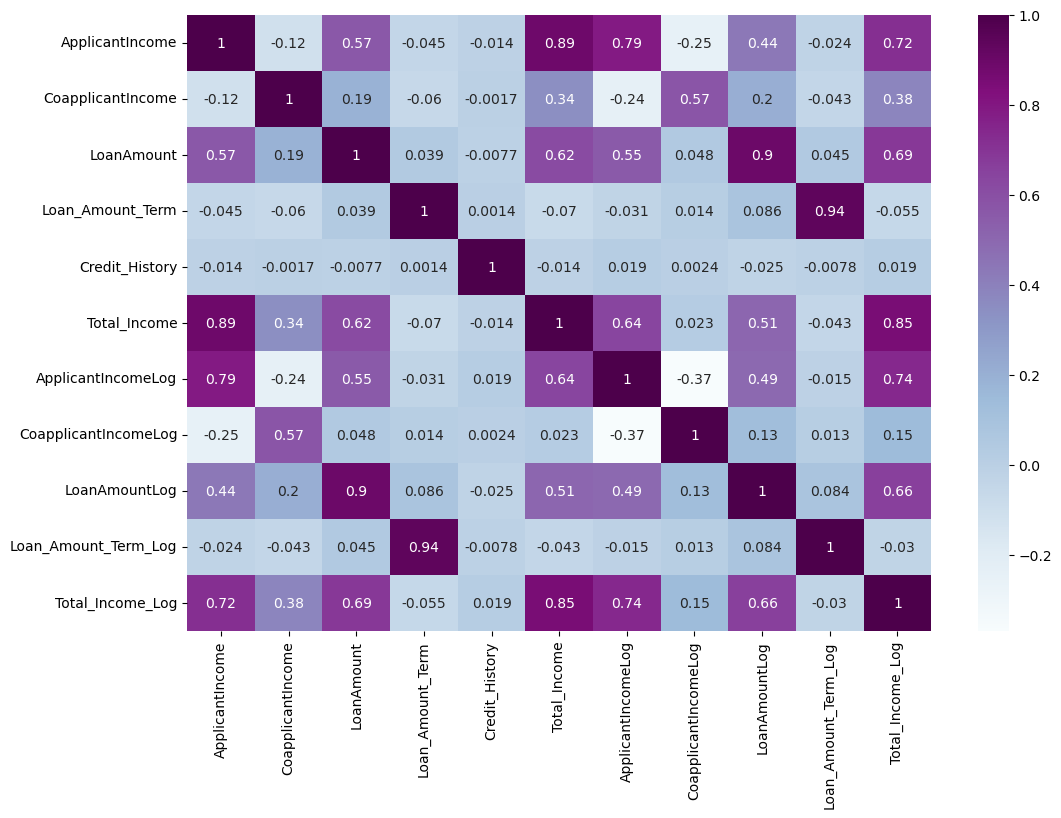

In [71]:
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='BuPu')
plt.show()

In [72]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income,ApplicantIncomeLog,CoapplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,LP001002,Male,No,0,Graduate,No,5849,0.0,146.412162,360.0,1.0,Urban,Y,5849.0,8.674197,0.000000,4.993232,5.888878,8.674197
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.000000,360.0,1.0,Rural,N,6091.0,8.430327,7.319202,4.859812,5.888878,8.714732
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.000000,360.0,1.0,Urban,Y,3000.0,8.006701,0.000000,4.204693,5.888878,8.006701
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.000000,360.0,1.0,Urban,Y,4941.0,7.857094,7.765993,4.795791,5.888878,8.505525
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.000000,360.0,1.0,Urban,Y,6000.0,8.699681,0.000000,4.955827,5.888878,8.699681


In [73]:
cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount','Loan_Amount_Term', 'Total_Income', 'Loan_ID', 'CoapplicantIncomeLog']
df = df.drop(columns=cols)
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,Male,No,0,Graduate,No,1.0,Urban,Y,8.674197,4.993232,5.888878,8.674197
1,Male,Yes,1,Graduate,No,1.0,Rural,N,8.430327,4.859812,5.888878,8.714732
2,Male,Yes,0,Graduate,Yes,1.0,Urban,Y,8.006701,4.204693,5.888878,8.006701
3,Male,Yes,0,Not Graduate,No,1.0,Urban,Y,7.857094,4.795791,5.888878,8.505525
4,Male,No,0,Graduate,No,1.0,Urban,Y,8.699681,4.955827,5.888878,8.699681


## Label Encoding

In [74]:
from sklearn.preprocessing import LabelEncoder
cols = ['Gender',"Married","Education",'Self_Employed',"Property_Area","Loan_Status","Dependents"]
le = LabelEncoder()
for col in cols:
    df[col] = le.fit_transform(df[col])

In [75]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Credit_History,Property_Area,Loan_Status,ApplicantIncomeLog,LoanAmountLog,Loan_Amount_Term_Log,Total_Income_Log
0,1,0,0,0,0,1.0,2,1,8.674197,4.993232,5.888878,8.674197
1,1,1,1,0,0,1.0,0,0,8.430327,4.859812,5.888878,8.714732
2,1,1,0,0,1,1.0,2,1,8.006701,4.204693,5.888878,8.006701
3,1,1,0,1,0,1.0,2,1,7.857094,4.795791,5.888878,8.505525
4,1,0,0,0,0,1.0,2,1,8.699681,4.955827,5.888878,8.699681


## Train-Test Split

In [76]:
# specify input and output attributes
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

In [77]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Model Training

In [78]:
def classify(model, x, y):    
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)
    model.fit(x_train, y_train)
    print("Accuracy:", model.score(x_test, y_test) * 100)
    # cross validation
    score = cross_val_score(model, x, y, cv=5)
    print("Cross validation:", np.mean(score) * 100)

In [79]:
model = LogisticRegression()
classify(model, X, y)

Accuracy: 77.27272727272727
Cross validation: 80.9462881514061


In [80]:
model = DecisionTreeClassifier()
classify(model, X, y)

Accuracy: 73.37662337662337
Cross validation: 71.98853791816606


In [81]:
model = RandomForestClassifier()
classify(model, X, y)

Accuracy: 76.62337662337663
Cross validation: 78.17939490870319


In [82]:
model = ExtraTreesClassifier()
classify(model, X, y)

Accuracy: 72.07792207792207
Cross validation: 77.03851792616287


## Hyperparameter tuning

In [83]:
model = RandomForestClassifier(n_estimators=100, min_samples_split=25, max_depth=7, max_features=1)
classify(model, X, y)

Accuracy: 75.97402597402598
Cross validation: 80.45848327335733


## Confusion Matrix

A confusion matrix is a summary of prediction results on a classification problem. The number of correct and incorrect predictions are summarized with count values and broken down by each class. It gives us insight not only into the errors being made by a classifier but more importantly the types of errors that are being made.

In [84]:
model = RandomForestClassifier()
model.fit(x_train, y_train)

RandomForestClassifier()

In [85]:

# confusion matrix
y_pred = model.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
cm

array([[22, 32],
       [ 3, 97]])

<Axes: >

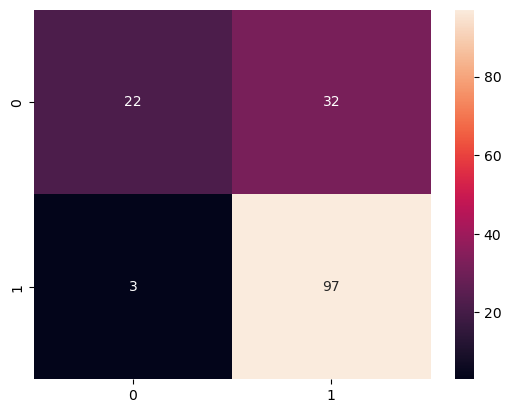

In [86]:
sns.heatmap(cm, annot=True)